<style>
table {
  margin-left: 0 !important;
  margin-right: auto !important;
}
th, td {
  text-align: left !important;
}
</style>

## Decision Variables, Objectives, and Constraints

An optimization problem starts with three simple questions.

| Question | Name | Meaning |
|:---|:---|:---|
| What can we choose? | **Decision variable** | The action we control |
| What should improve? | **Objective** | The result used to compare plans |
| What rules must hold? | **Constraint** | A condition every usable plan must satisfy |

### 1 · Start with one short story

> A workshop chooses how many units of products A and B to make. It wants more profit, but it has only 18 units of work time and 10 units of material.

So the model is:

- **Choose:** the quantities of A and B
- **Improve:** total profit
- **Keep:** work time and material within their limits

<div style="text-align: left; margin: 0.65rem 0 1.5rem 0;">
  <img src="https://raw.githubusercontent.com/sonamu-jun/system-design-and-optimization/main/01-2_decision_variables_objective_constraints/assets/02_production_problem_labeled.png" alt="A workshop story separated into its decision, goal, and two rules" width="720" style="display: block; max-width: 100%; height: auto; margin: 0;">
</div>

### 2 · Give the choices short names

| Choice | Symbol | Possible values |
|:---|:---:|:---|
| Number of A units | $x_A$ | $0,1,2,\ldots,10$ |
| Number of B units | $x_B$ | $0,1,2,\ldots,10$ |

The symbols only shorten the story. Because the workshop makes whole products, both choices are whole numbers.

### 3 · Calculate one plan

| Product | Profit per unit | Work time per unit | Material per unit |
|:---:|---:|---:|---:|
| A | 30 | 2 | 1 |
| B | 50 | 3 | 2 |

For the plan $(x_A,x_B)=(2,3)$:

> **Profit:** $30\times2+50\times3=210$  
> **Work time:** $2\times2+3\times3=13\le18$  
> **Material:** $1\times2+2\times3=8\le10$

The same calculation for any plan is:

> **Choose:** $x_A,x_B\in\{0,1,\ldots,10\}$  
> **Improve:** profit $=30x_A+50x_B$  
> **Keep:** $2x_A+3x_B\le18$ and $x_A+2x_B\le10$

The next cell checks three plans. A plan that breaks a rule is rejected before profits are compared.

In [1]:
# Notebook-local production-planning demonstrations.

import matplotlib

PRODUCT_A = {"profit": 30, "labor": 2, "material": 1}
PRODUCT_B = {"profit": 50, "labor": 3, "material": 2}
MATERIAL_LIMIT = 10
QUANTITY_LIMIT = 10
LABOR_LIMITS = tuple(range(14, 23))
OBJECTIVES = ("profit", "throughput", "product_b")


def evaluate_production_plan(x_a, x_b, labor_limit=18, material_limit=MATERIAL_LIMIT):
    """Return objective, resource responses, slack, and feasibility for one plan."""
    x_a = int(round(x_a))
    x_b = int(round(x_b))
    labor_limit = int(round(labor_limit))
    material_limit = int(round(material_limit))

    profit = PRODUCT_A["profit"] * x_a + PRODUCT_B["profit"] * x_b
    labor = PRODUCT_A["labor"] * x_a + PRODUCT_B["labor"] * x_b
    material = PRODUCT_A["material"] * x_a + PRODUCT_B["material"] * x_b
    labor_slack = labor_limit - labor
    material_slack = material_limit - material
    domain_ok = 0 <= x_a <= QUANTITY_LIMIT and 0 <= x_b <= QUANTITY_LIMIT
    feasible = domain_ok and labor_slack >= 0 and material_slack >= 0

    return {
        "x_a": x_a,
        "x_b": x_b,
        "profit": profit,
        "labor": labor,
        "material": material,
        "throughput": x_a + x_b,
        "labor_limit": labor_limit,
        "material_limit": material_limit,
        "labor_slack": labor_slack,
        "material_slack": material_slack,
        "feasible": feasible,
        "score": -float(profit) if feasible else float("inf"),
    }


def objective_value(record, objective="profit"):
    """Return the declared comparison value for one evaluated plan."""
    if objective == "profit":
        return record["profit"]
    if objective == "throughput":
        return record["throughput"]
    if objective == "product_b":
        return record["x_b"]
    raise ValueError(f"Unknown objective: {objective!r}")


def find_best_production_plans(
    objective="profit", labor_limit=18, material_limit=MATERIAL_LIMIT
):
    """Return every feasible plan tied under the declared objective."""
    if objective not in OBJECTIVES:
        raise ValueError(f"objective must be one of {OBJECTIVES}")
    feasible = [
        record for record in enumerate_candidates(labor_limit, material_limit)
        if record["feasible"]
    ]
    if not feasible:
        return []
    best_value = max(objective_value(record, objective) for record in feasible)
    return [
        record for record in feasible
        if objective_value(record, objective) == best_value
    ]


def enumerate_candidates(labor_limit=18, material_limit=MATERIAL_LIMIT):
    """Evaluate the complete 11 by 11 integer search space."""
    return [
        evaluate_production_plan(x_a, x_b, labor_limit, material_limit)
        for x_a in range(QUANTITY_LIMIT + 1)
        for x_b in range(QUANTITY_LIMIT + 1)
    ]


def find_best_production_plan(labor_limit=18, material_limit=MATERIAL_LIMIT):
    """Return the first maximum-profit feasible plan in enumeration order."""
    best_plans = find_best_production_plans(
        "profit", labor_limit=labor_limit, material_limit=material_limit
    )
    return best_plans[-1] if best_plans else None


def labor_sensitivity(labor_limits=LABOR_LIMITS, material_limit=MATERIAL_LIMIT):
    """Re-solve the production model for each supplied labor limit."""
    return [find_best_production_plan(limit, material_limit) for limit in labor_limits]


def show_plan_checks(plans=((2, 3), (6, 2), (10, 0)), labor_limit=18,
                     material_limit=MATERIAL_LIMIT):
    """Print a few concrete plans in calculate -> check-rules order."""
    results = [
        evaluate_production_plan(x_a, x_b, labor_limit, material_limit)
        for x_a, x_b in plans
    ]
    for result in results:
        status = "KEEP" if result["feasible"] else "REJECT"
        print(
            f"plan ({result['x_a']}, {result['x_b']}): "
            f"profit={result['profit']}, "
            f"work time={result['labor']}/{labor_limit}, "
            f"material={result['material']}/{material_limit} -> {status}"
        )
    return results


def show_goal_choices(labor_limit=18, material_limit=MATERIAL_LIMIT):
    """Keep the valid plans fixed and print the winner for three goals."""
    valid_plans = [
        record for record in enumerate_candidates(labor_limit, material_limit)
        if record["feasible"]
    ]
    print(f"{len(valid_plans)} plans follow both rules.")
    goal_labels = (
        ("profit", "earn more profit"),
        ("throughput", "make more products"),
        ("product_b", "make more product B"),
    )
    winners_by_goal = {}
    for objective, label in goal_labels:
        winners = find_best_production_plans(
            objective, labor_limit=labor_limit, material_limit=material_limit
        )
        plans = [(record["x_a"], record["x_b"]) for record in winners]
        winners_by_goal[objective] = winners
        print(f"{label:>20} -> {plans}")
    return {"valid_plans": valid_plans, "winners": winners_by_goal}


def show_four_system_examples():
    """Display the production, staffing, delivery, and battery examples."""
    return show_formulation_gallery()


def show_same_rules_different_goals():
    """Display the same valid production plans under three goals."""
    return show_objective_comparison()


def show_plan_and_goal_examples():
    """Run the rule-checking and goal-comparison examples as one lesson step."""
    plan_results = show_plan_checks()
    print()
    goal_results = show_goal_choices()
    return {"plan_results": plan_results, "goal_results": goal_results}


def show_visual_explanations():
    """Display the four-system gallery and the three-goal comparison."""
    show_formulation_gallery()
    show_objective_comparison()


def show_work_time_explorer():
    """Run the work-time comparison and open the interactive explorer."""
    from types import SimpleNamespace

    work_time_results = show_work_time_what_if()
    explorer = show_interactive_explorer()
    return SimpleNamespace(
        work_time_results=work_time_results,
        explorer=explorer,
        state=explorer.state,
    )


def show_work_time_what_if(work_time_limits=LABOR_LIMITS,
                           material_limit=MATERIAL_LIMIT):
    """Print and plot the controlled work-time comparison."""
    results = labor_sensitivity(work_time_limits, material_limit)
    print(f"{'work time':>9} | {'best plan':>10} | {'profit':>6}")
    print("-" * 32)
    for result in results:
        plan = (result["x_a"], result["x_b"])
        print(f"{result['labor_limit']:>9} | {str(plan):>10} | {result['profit']:>6}")
    show_system_behavior()
    return results


def _active_constraint_text(record):
    active = []
    if record["labor_slack"] == 0:
        active.append("work time")
    if record["material_slack"] == 0:
        active.append("material")
    return " + ".join(active) if active else "none"


def _slider_insight(current, best, previous=None):
    """Explain what the last slider move means and what the model reveals."""
    plan = (current["x_a"], current["x_b"])
    best_plan = (best["x_a"], best["x_b"])

    if previous:
        previous_plan = (previous["x_a"], previous["x_b"])
        if plan != previous_plan and current["labor_limit"] == previous["labor_limit"]:
            change = f"DECISION CHANGED: plan {previous_plan} → {plan}"
        elif plan == previous_plan and current["labor_limit"] != previous["labor_limit"]:
            change = (
                "SITUATION CHANGED: available work time "
                f"{previous['labor_limit']} → {current['labor_limit']}"
            )
        else:
            change = "MORE THAN ONE INPUT CHANGED: compare one slider at a time"
    else:
        change = "START: blue sliders change the decision; the purple slider changes the situation"

    if not current["feasible"]:
        violations = []
        if current["labor_slack"] < 0:
            violations.append(f"work time by {-current['labor_slack']}")
        if current["material_slack"] < 0:
            violations.append(f"material by {-current['material_slack']}")
        insight = (
            "RULE INSIGHT: reject before comparing profit; this plan exceeds "
            + " and ".join(violations)
        )
    elif plan == best_plan:
        if current["material_slack"] == 0 and current["labor_limit"] >= 20:
            insight = (
                "GOAL INSIGHT: this is a best plan; more work time alone cannot help "
                "because all material is already used"
            )
        else:
            used_up = _active_constraint_text(current)
            insight = (
                f"GOAL INSIGHT: this is a best profit plan; fully used resource: {used_up}"
            )
    else:
        gap = best["profit"] - current["profit"]
        if current["material_slack"] == 0:
            reason = "material is full, so changing the product mix matters"
        elif current["labor_slack"] == 0:
            reason = "work time is full, so changing the product mix matters"
        else:
            reason = "some resources remain unused"
        insight = (
            f"COMPARISON INSIGHT: valid but {gap} profit below best; {reason}"
        )
    return change, insight


def _plot_feasible_set(axis, labor_limit, current=None, *, show_examples=False):
    """Draw integer candidates, resource boundaries, and the best plan."""
    import numpy as np

    records = enumerate_candidates(labor_limit)
    feasible = [record for record in records if record["feasible"]]
    infeasible = [record for record in records if not record["feasible"]]
    best = find_best_production_plan(labor_limit)

    axis.scatter(
        [record["x_a"] for record in infeasible],
        [record["x_b"] for record in infeasible],
        marker="x", s=20, color="#c9c9c9", label="Breaks at least one rule",
    )
    points = axis.scatter(
        [record["x_a"] for record in feasible],
        [record["x_b"] for record in feasible],
        c=[record["profit"] for record in feasible],
        cmap="viridis", s=38, edgecolor="white", linewidth=0.35,
        label="Follows both rules",
    )

    x_line = np.linspace(0, QUANTITY_LIMIT, 300)
    labor_boundary = (labor_limit - 2 * x_line) / 3
    material_boundary = (MATERIAL_LIMIT - x_line) / 2
    axis.plot(x_line, labor_boundary, color="tab:red", linewidth=1.6,
              label=f"Work-time rule, limit={labor_limit}")
    axis.plot(x_line, material_boundary, color="tab:blue", linewidth=1.6,
              label="Material rule, limit=10")

    if best is not None:
        axis.scatter(best["x_a"], best["x_b"], marker="*", s=230,
                     color="gold", edgecolor="black", zorder=6, label="Best profit plan")
        axis.annotate(
            f"best plan ({best['x_a']}, {best['x_b']})\nprofit {best['profit']}",
            (best["x_a"], best["x_b"]), xytext=(8, 8),
            textcoords="offset points", fontsize=8,
        )

    if show_examples:
        for x_a, x_b in ((1, 4), (8, 1)):
            record = evaluate_production_plan(x_a, x_b, labor_limit)
            axis.annotate(
                f"({x_a}, {x_b})\nP={record['profit']}",
                (x_a, x_b), xytext=(-30, -28 if record["feasible"] else 10),
                textcoords="offset points", fontsize=7,
                arrowprops={"arrowstyle": "-", "color": "#666666", "lw": 0.7},
            )

    if current is not None:
        axis.scatter(current["x_a"], current["x_b"], marker="s", s=105,
                     color="tab:orange", edgecolor="black", zorder=7, label="Current plan")

    axis.set(
        xlim=(-0.5, QUANTITY_LIMIT + 0.5),
        ylim=(-0.5, QUANTITY_LIMIT + 0.5),
        xlabel="Product A units",
        ylabel="Product B units",
        title="Which plans follow both rules?",
    )
    axis.set_xticks(range(0, QUANTITY_LIMIT + 1, 2))
    axis.set_yticks(range(0, QUANTITY_LIMIT + 1, 2))
    axis.grid(alpha=0.18)
    return points, best


def show_formulation_gallery():
    """Show the same three plain-language questions in four systems."""
    import matplotlib.pyplot as plt
    import numpy as np
    from matplotlib.colors import ListedColormap

    figure, axes = plt.subplots(2, 2, figsize=(11.8, 10.0))

    # Production: integer quantities create resource use and profit.
    axis = axes[0, 0]
    feasible = [record for record in enumerate_candidates(18) if record["feasible"]]
    best = find_best_production_plan(18)
    axis.scatter(
        [record["x_a"] for record in feasible],
        [record["x_b"] for record in feasible],
        c=[record["profit"] for record in feasible],
        cmap="viridis",
        s=42,
        edgecolor="white",
        linewidth=0.4,
    )
    x_line = np.linspace(0, QUANTITY_LIMIT, 200)
    axis.plot(x_line, (18 - 2 * x_line) / 3, color="#d1495b", linewidth=1.5,
              label="work-time rule")
    axis.plot(x_line, (MATERIAL_LIMIT - x_line) / 2, color="#2678c9", linewidth=1.5,
              label="material rule")
    axis.scatter(best["x_a"], best["x_b"], marker="*", s=250, color="#f4b942",
                 edgecolor="#233248", linewidth=0.9, zorder=4, label="best profit plan")
    axis.set(
        xlim=(-0.4, 10.4), ylim=(-0.4, 6.2),
        xlabel="CHOOSE: Product A units",
        ylabel="CHOOSE: Product B units",
        title="Production\nWANT: more profit\nKEEP: within work time and materials",
    )
    axis.grid(alpha=0.18)
    axis.legend(fontsize=7.5, loc="upper right")

    # Staffing: each colored cell is one yes/no worker-slot decision.
    axis = axes[0, 1]
    assignment = np.array([
        [1, 1, 1, 0, 0, 0],
        [1, 1, 1, 1, 0, 0],
        [0, 1, 1, 1, 1, 0],
        [0, 0, 1, 1, 1, 1],
    ])
    axis.imshow(assignment, cmap=ListedColormap(["#edf1f6", "#159a8c"]),
                vmin=0, vmax=1, aspect="auto")
    for row in range(assignment.shape[0]):
        for column in range(assignment.shape[1]):
            axis.text(column, row, "1" if assignment[row, column] else "0",
                      ha="center", va="center", fontsize=9,
                      color="white" if assignment[row, column] else "#8b96a8")
    coverage = assignment.sum(axis=0)
    axis.set(
        xticks=range(6), xticklabels=[f"t{index}" for index in range(1, 7)],
        yticks=range(4), yticklabels=["worker A", "worker B", "worker C", "worker D"],
        xlabel="Workers scheduled in each slot: " + "  ".join(str(value) for value in coverage),
        title=("Staffing\nCHOOSE: who works in each time slot\n"
               "WANT: lower cost · KEEP: enough staff"),
    )
    axis.tick_params(length=0)

    # Delivery: the sequence is the decision; distance and load are responses.
    axis = axes[1, 0]
    coordinates = {
        "depot": np.array([0.0, 0.0]),
        "A": np.array([1.0, 2.0]),
        "B": np.array([3.0, 3.0]),
        "C": np.array([4.0, 1.0]),
    }
    route = ("depot", "A", "B", "C", "depot")
    route_points = np.array([coordinates[name] for name in route])
    distance = sum(
        np.linalg.norm(coordinates[first] - coordinates[second])
        for first, second in zip(route[:-1], route[1:])
    )
    axis.plot(route_points[:, 0], route_points[:, 1], color="#ef8622", linewidth=2.5,
              marker="o", markersize=8)
    for name, point in coordinates.items():
        axis.text(point[0], point[1] + 0.18, name, ha="center", fontsize=9,
                  fontweight="bold", color="#233248")
    for index in range(len(route) - 1):
        midpoint = (route_points[index] + route_points[index + 1]) / 2
        axis.text(midpoint[0], midpoint[1], str(index + 1), ha="center", va="center",
                  fontsize=8, color="white",
                  bbox={"boxstyle": "circle,pad=0.22", "fc": "#ef8622", "ec": "none"})
    axis.set(
        xlim=(-0.6, 4.6), ylim=(-0.5, 3.6),
        title="Delivery\nCHOOSE: the visiting order\nWANT: shorter trip · KEEP: visit all, no overload",
    )
    axis.set_aspect("equal", adjustable="box")
    axis.set_xticks([])
    axis.set_yticks([])
    axis.spines[:].set_visible(False)
    axis.text(
        0.02, 0.04, f"total travel distance = {distance:.1f}", transform=axis.transAxes,
        fontsize=8.5, color="#637289",
    )

    # Battery: time-indexed continuous actions move a state inside safe bounds.
    axis = axes[1, 1]
    periods = np.arange(1, 7)
    prices = np.array([90, 60, 40, 70, 120, 140])
    power = np.array([0, 2, 2, 0, -2, -2])
    state = np.r_[50, 50 + 10 * np.cumsum(power)]
    colors = ["#159a8c" if value >= 0 else "#7655a6" for value in power]
    bars = axis.bar(periods, power, color=colors, width=0.62, alpha=0.88,
                    label="charge (+) / use battery (−)")
    axis.axhline(0, color="#233248", linewidth=0.9)
    axis.set(
        xticks=periods,
        xticklabels=[f"t{period}\n{price}" for period, price in zip(periods, prices)],
        xlabel="Time period / electricity price",
        ylabel="CHOOSE: charge or use battery",
        ylim=(-2.8, 2.8),
        title=("Battery\nCHOOSE: when to charge or use energy\n"
               "WANT: lower bill · KEEP: battery safe"),
    )
    state_axis = axis.twinx()
    state_axis.axhspan(20, 90, color="#2678c9", alpha=0.08)
    state_axis.plot(np.arange(0, 7), state, color="#2678c9", marker="o",
                    linewidth=2.2, label="energy state")
    state_axis.set(ylabel="Stored energy", ylim=(0, 100))
    lines = [bars, state_axis.lines[0]]
    labels = ["Charge/use decision", "Stored energy"]
    axis.legend(lines, labels, fontsize=7.5, loc="lower left")
    axis.grid(axis="y", alpha=0.18)

    figure.suptitle(
        "Four everyday problems · the same three questions",
        fontsize=14,
        fontweight="bold",
    )
    figure.text(
        0.5, 0.94,
        "What can be chosen?   What should get better?   What must be kept?",
        ha="center", va="center", fontsize=10.5, color="#637289",
    )
    for axis in axes.flat:
        axis.title.set_fontsize(11)
        axis.title.set_linespacing(1.25)
    figure.tight_layout(rect=(0, 0.01, 1, 0.89), h_pad=4.2, w_pad=2.6)
    plt.show()
    plt.close(figure)
    return figure


def show_objective_comparison():
    """Hold the valid plans fixed and change only the meaning of better."""
    import matplotlib.pyplot as plt

    labor_limit = 18
    feasible = [
        record for record in enumerate_candidates(labor_limit)
        if record["feasible"]
    ]
    specifications = (
        ("profit", "Goal: earn more profit", "profit", "#d99000"),
        ("throughput", "Goal: make more products", "units", "#159a8c"),
        ("product_b", "Goal: make more product B", "B units", "#7b5bac"),
    )

    figure, axes = plt.subplots(3, 1, figsize=(8.8, 10.8), sharex=True, sharey=True)
    for axis, (objective, title, unit, color) in zip(axes, specifications):
        winners = find_best_production_plans(objective, labor_limit=labor_limit)
        axis.scatter(
            [record["x_a"] for record in feasible],
            [record["x_b"] for record in feasible],
            s=33,
            color="#d8dee8",
            edgecolor="white",
            linewidth=0.4,
        )
        axis.scatter(
            [record["x_a"] for record in winners],
            [record["x_b"] for record in winners],
            marker="*",
            s=220,
            color=color,
            edgecolor="#233248",
            linewidth=0.8,
            zorder=4,
        )
        best_value = objective_value(winners[0], objective)
        plans = ", ".join(f"({r['x_a']}, {r['x_b']})" for r in winners)
        axis.set_title(
            f"{title}  →  {plans} · {best_value} {unit}",
            fontsize=11,
            loc="left",
            pad=7,
        )
        axis.set(
            xlim=(-0.5, QUANTITY_LIMIT + 0.5),
            ylim=(-0.5, 6.2),
            ylabel="Product B units",
        )
        axis.set_xticks(range(0, QUANTITY_LIMIT + 1, 2))
        axis.set_yticks(range(0, 7))
        axis.grid(alpha=0.18)
    axes[-1].set_xlabel("Product A units")
    figure.suptitle(
        "Same valid plans · a different goal can choose a different answer",
        fontsize=13.5,
        fontweight="bold",
    )
    figure.text(
        0.5, 0.955,
        "All gray dots follow both rules. Each star is the best plan for one goal.",
        ha="center", va="center", fontsize=9.5, color="#637289",
    )
    figure.tight_layout(rect=(0, 0, 1, 0.92), h_pad=2.2)
    plt.show()
    plt.close(figure)
    return figure


def show_system_behavior():
    """Show rule checking, best-so-far updates, and changing work time."""
    import matplotlib.pyplot as plt

    labor_limit = 18
    records = enumerate_candidates(labor_limit)
    feasible = [record for record in records if record["feasible"]]
    sensitivity = labor_sensitivity()

    incumbent_profit = []
    best_so_far = -1
    for record in feasible:
        best_so_far = max(best_so_far, record["profit"])
        incumbent_profit.append(best_so_far)

    figure, axes = plt.subplots(3, 1, figsize=(8.8, 12.0))
    _plot_feasible_set(axes[0], labor_limit, show_examples=True)
    axes[0].legend(fontsize=7, loc="upper right")

    axes[1].step(range(1, len(feasible) + 1), incumbent_profit,
                 where="post", linewidth=2.2, color="tab:purple")
    updates = [
        index for index, value in enumerate(incumbent_profit)
        if index == 0 or value > incumbent_profit[index - 1]
    ]
    axes[1].scatter(
        [index + 1 for index in updates],
        [incumbent_profit[index] for index in updates],
        color="tab:orange", s=34, zorder=3, label="A better plan was found",
    )
    axes[1].set(
        xlabel="Number of valid plans checked",
        ylabel="Best profit seen so far",
        title="The best-so-far plan changes while checking the list",
    )
    axes[1].grid(alpha=0.25)
    axes[1].legend(fontsize=8)

    limits = [record["labor_limit"] for record in sensitivity]
    profits = [record["profit"] for record in sensitivity]
    axes[2].step(limits, profits, where="mid", linewidth=2.2, color="teal")
    axes[2].scatter(limits, profits, color="teal", s=38)
    previous_plan = None
    for record in sensitivity:
        plan = (record["x_a"], record["x_b"])
        if plan != previous_plan:
            axes[2].annotate(
                f"({record['x_a']},{record['x_b']})",
                (record["labor_limit"], record["profit"]),
                xytext=(0, 7), textcoords="offset points", ha="center", fontsize=8,
            )
        previous_plan = plan
    axes[2].axvline(20, color="tab:red", linestyle="--", linewidth=1.2,
                    label="After 20, material becomes the next limit")
    axes[2].set(
        xticks=LABOR_LIMITS,
        xlabel="Available work time, L",
        ylabel="Best profit",
        title="What happens when more work time is available?",
    )
    axes[2].grid(alpha=0.25)
    axes[2].legend(fontsize=7, loc="lower right")

    figure.suptitle(
        "Production planning · calculate → check rules → compare the goal",
        fontsize=13.5,
        fontweight="bold",
    )
    figure.tight_layout(rect=(0, 0, 1, 0.96), h_pad=2.4)
    plt.show()
    plt.close(figure)
    return figure


def show_interactive_explorer():
    """Link quantity and labor-limit sliders to one coherent model view."""
    import sys
    import matplotlib

    if sys.platform != "emscripten":
        try:
            matplotlib.use("widget", force=True)
        except (RuntimeError, ValueError):
            from matplotlib.backends import backend_registry
            backend_registry._clear()
            matplotlib.use("widget", force=True)

    import matplotlib.pyplot as plt
    from matplotlib.widgets import Slider
    from types import SimpleNamespace

    plt.close("all")
    figure = plt.figure(figsize=(10.6, 10.1))
    panels = figure.subplot_mosaic(
        [["resources", "decisions"], ["sensitivity", "sensitivity"]]
    )
    axes = (panels["resources"], panels["decisions"], panels["sensitivity"])
    figure.subplots_adjust(
        left=0.09, right=0.97, bottom=0.25, top=0.74, hspace=0.52, wspace=0.34
    )

    x_a_axis = figure.add_axes([0.34, 0.135, 0.56, 0.025])
    x_b_axis = figure.add_axes([0.34, 0.085, 0.56, 0.025])
    labor_axis = figure.add_axes([0.34, 0.035, 0.56, 0.025])
    x_a_slider = Slider(x_a_axis, "Choose product A units", 0, QUANTITY_LIMIT,
                        valinit=4, valstep=1)
    x_b_slider = Slider(x_b_axis, "Choose product B units", 0, QUANTITY_LIMIT,
                        valinit=3, valstep=1)
    labor_slider = Slider(labor_axis, "Available work time", 14, 22,
                          valinit=18, valstep=1, color="tab:purple")
    for slider, color in (
        (x_a_slider, "#2678c9"),
        (x_b_slider, "#2678c9"),
        (labor_slider, "#7d5cab"),
    ):
        slider.label.set_color(color)
        slider.label.set_fontweight("bold")

    status_text = figure.text(0.5, 0.985, "", ha="center", va="top",
                              fontsize=12, fontweight="bold")
    metrics_text = figure.text(0.5, 0.948, "", ha="center", va="top", fontsize=9.2)
    insight_text = figure.text(
        0.5, 0.872, "", ha="center", va="top", fontsize=9.3, color="#233248",
        bbox={"boxstyle": "round,pad=0.55", "fc": "#f4f7fb", "ec": "#b9c8dc"},
    )
    figure.text(
        0.5, 0.205,
        "Blue trackbars change the decision · the purple trackbar changes available work time",
        ha="center", va="center", fontsize=9.5, color="#52647a", fontweight="bold",
    )
    current_state = {}
    sensitivity = labor_sensitivity()

    def refresh(_=None):
        x_a = int(round(x_a_slider.val))
        x_b = int(round(x_b_slider.val))
        labor_limit = int(round(labor_slider.val))
        current = evaluate_production_plan(x_a, x_b, labor_limit)
        best = find_best_production_plan(labor_limit)
        change, insight = _slider_insight(current, best, current_state)

        for axis in axes:
            axis.clear()

        usage = [current["labor"] / labor_limit, current["material"] / MATERIAL_LIMIT]
        colors = ["#2a9d8f" if value <= 1 else "#d1495b" for value in usage]
        axes[0].bar(["Labor", "Material"], usage, color=colors, width=0.62)
        axes[0].axhline(1, color="black", linestyle="--", linewidth=1.2,
                       label="100% of available amount")
        for index, value in enumerate(usage):
            axes[0].text(index, value + 0.04, f"{100 * value:.0f}%",
                         ha="center", fontsize=9)
        axes[0].set(
            ylim=(0, max(1.35, max(usage) + 0.18)),
            ylabel="Share of available amount",
            title=f"Plan ({x_a}, {x_b}) · profit {current['profit']}",
        )
        axes[0].grid(axis="y", alpha=0.25)
        axes[0].legend(fontsize=8)

        _plot_feasible_set(axes[1], labor_limit, current=current)
        axes[1].legend(fontsize=6.8, loc="upper right")

        limits = [record["labor_limit"] for record in sensitivity]
        profits = [record["profit"] for record in sensitivity]
        axes[2].step(limits, profits, where="mid", linewidth=2.2, color="teal")
        axes[2].scatter(limits, profits, color="teal", s=38)
        axes[2].axvline(labor_limit, color="tab:orange", linewidth=2,
                        label=f"Current work time={labor_limit}")
        axes[2].scatter(labor_limit, best["profit"], marker="*", s=210,
                        color="gold", edgecolor="black", zorder=4,
                        label=f"Best plan ({best['x_a']}, {best['x_b']})")
        axes[2].set(
            xticks=LABOR_LIMITS,
            xlabel="Available work time, L",
            ylabel="Best profit",
            title="Best profit at each work-time limit",
        )
        axes[2].grid(alpha=0.25)
        axes[2].legend(fontsize=7, loc="lower right")

        status = "FOLLOWS BOTH RULES" if current["feasible"] else "BREAKS A RULE"
        status_text.set_text(f"Current plan ({x_a}, {x_b}) · {status}")
        status_text.set_color("#087f5b" if current["feasible"] else "#c92a2a")
        metrics_text.set_text(
            f"profit={current['profit']}  |  work time used={current['labor']}/{labor_limit} "
            f"|  material used={current['material']}/10\n"
            f"best profit plan=({best['x_a']}, {best['x_b']})  |  "
            f"profit={best['profit']}  |  fully used: {_active_constraint_text(best)}"
        )
        insight_text.set_text(f"{change}\n{insight}")
        insight_text.get_bbox_patch().set_edgecolor(
            "#9ac8b8" if current["feasible"] else "#e5a4ad"
        )
        current_state.clear()
        current_state.update(
            x_a=x_a,
            x_b=x_b,
            labor_limit=labor_limit,
            current=current,
            best=best,
            sensitivity=sensitivity,
            change=change,
            insight=insight,
        )
        figure.canvas.draw_idle()

    for slider in (x_a_slider, x_b_slider, labor_slider):
        slider.on_changed(refresh)
    figure._concept_sliders = (x_a_slider, x_b_slider, labor_slider)
    refresh()
    plt.show()
    if sys.platform != "emscripten":
        try:
            from matplotlib_inline import backend_inline
            backend_inline.show._to_draw = []
            backend_inline.show._draw_called = False
        except (ImportError, AttributeError):
            pass
    return SimpleNamespace(
        figure=figure,
        state=current_state,
        refresh=refresh,
        evaluate=evaluate_production_plan,
        x_a_slider=x_a_slider,
        x_b_slider=x_b_slider,
        labor_slider=labor_slider,
        insight_text=insight_text,
    )


# Backward-compatible name for small external checks built around the first draft.
def _evaluate(first, second, setting):
    return evaluate_production_plan(first, second, setting)


In [2]:
plan_results = show_plan_checks()

plan (2, 3): profit=210, work time=13/18, material=8/10 -> KEEP
plan (6, 2): profit=280, work time=18/18, material=10/10 -> KEEP
plan (10, 0): profit=300, work time=20/18, material=10/10 -> REJECT


Plan $(2,3)$ is usable because it follows both rules. Plan $(10,0)$ earns more profit, but it uses too much work time, so it is rejected.

> **calculate the result → check the constraints → compare the objective**

### 4 · The same three questions appear in many systems

The shape of a decision depends on the action: quantities in production, yes/no assignments in staffing, a visiting order in delivery, or an amount at each time in a battery system.

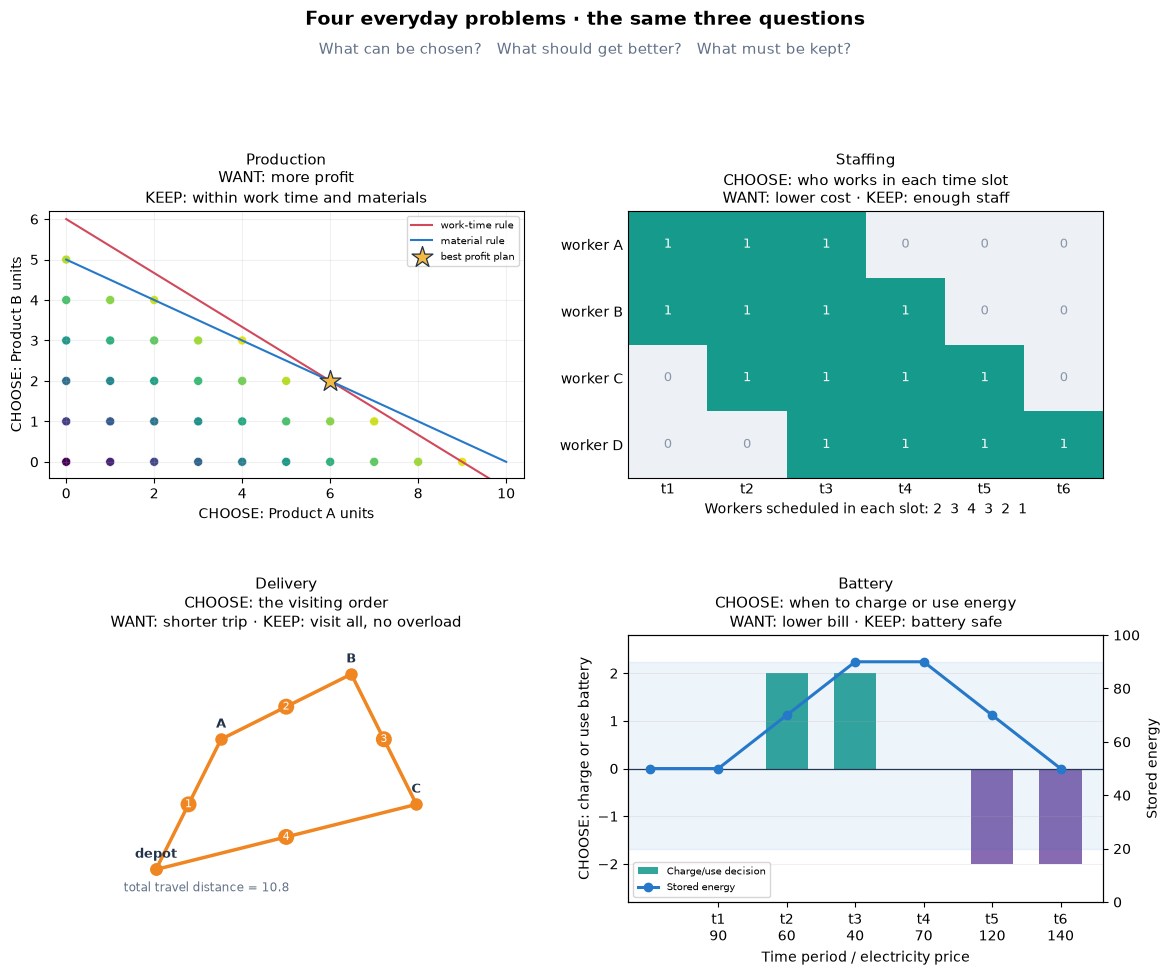

In [3]:
systems_figure = show_four_system_examples()

### 5 · A different objective can select a different plan

The constraints leave 34 usable production plans. The gray dots below stay the same; only the meaning of “better” changes.

- More profit selects $(6,2)$.
- More total products selects $(9,0)$.
- More product B selects $(0,5)$.

There is no plan that is best for every purpose. The objective must state what matters for this decision.

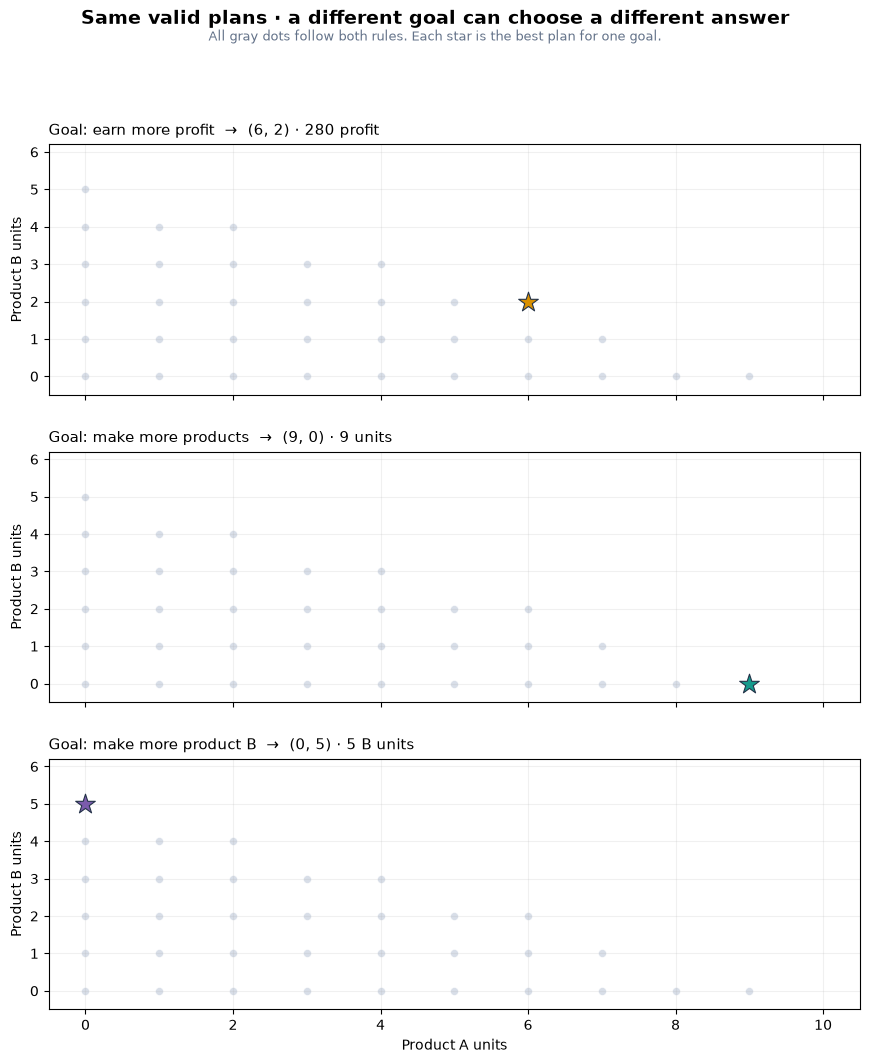

In [4]:
goals_figure = show_same_rules_different_goals()

### 6 · A changed limit creates a changed situation

Now keep the products, profit values, material limit, and objective fixed. Change only available work time from 14 to 22. This is a controlled **what-if** question.

The next cell prints the best plan at each work-time limit. The graph after it is in its own cell so its output remains separate.

In [5]:
work_time_results = labor_sensitivity()
print(f"{'work time':>9} | {'best plan':>10} | {'profit':>6}")
print("-" * 32)
for result in work_time_results:
    plan = (result["x_a"], result["x_b"])
    print(f"{result['labor_limit']:>9} | {str(plan):>10} | {result['profit']:>6}")

work time |  best plan | profit
--------------------------------
       14 |     (1, 4) |    230
       15 |     (0, 5) |    250
       16 |     (2, 4) |    260
       17 |     (4, 3) |    270
       18 |     (6, 2) |    280
       19 |     (8, 1) |    290
       20 |    (10, 0) |    300
       21 |    (10, 0) |    300
       22 |    (10, 0) |    300


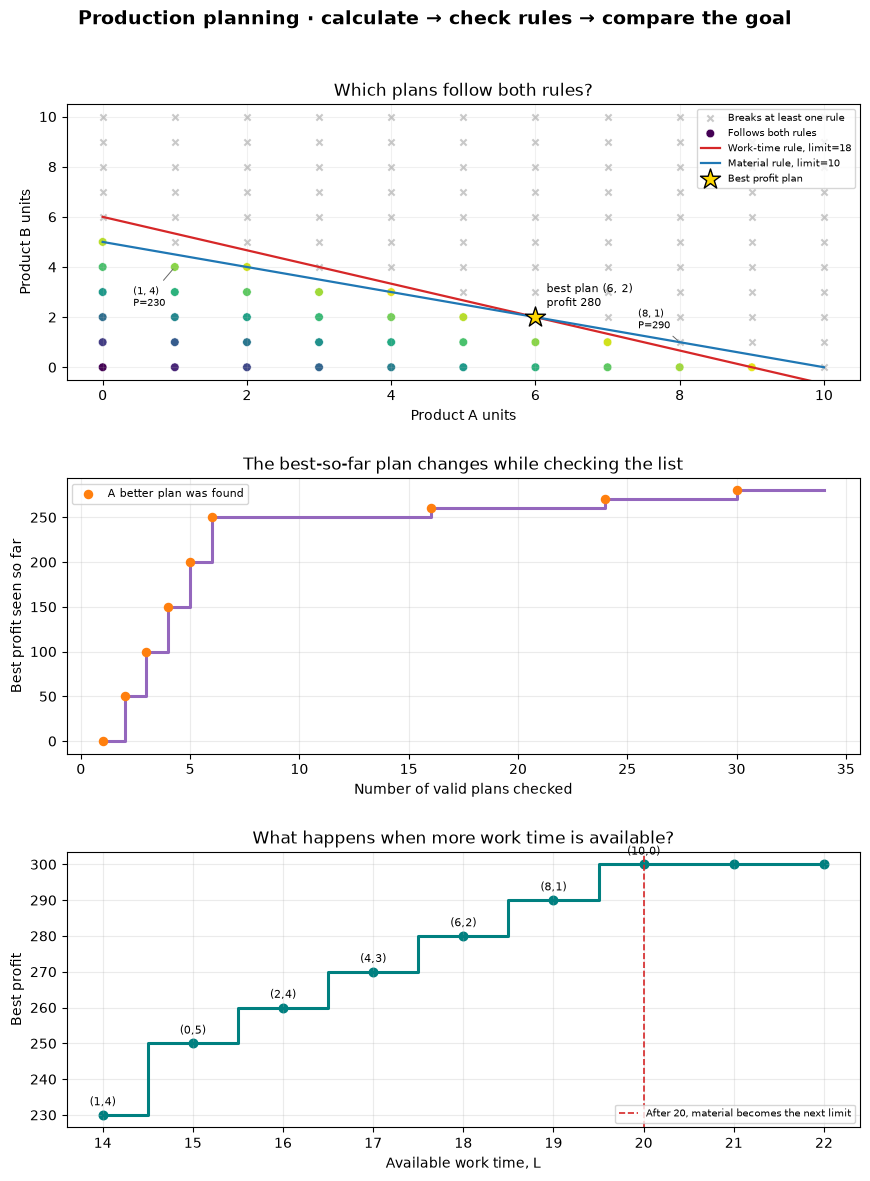

In [6]:
work_time_figure = show_system_behavior()

### 7 · Explore one decision at a time

Use the trackbars in the final graph:

- The two **blue** trackbars change the decision $(x_A,x_B)$.
- The **purple** trackbar changes the available work time.
- First check whether the current plan follows the rules, then compare it with the best usable plan.

Try $(4,3)$, $(6,2)$, and $(10,0)$ with work time 18. Then raise work time to 20 and observe why the last plan becomes usable.

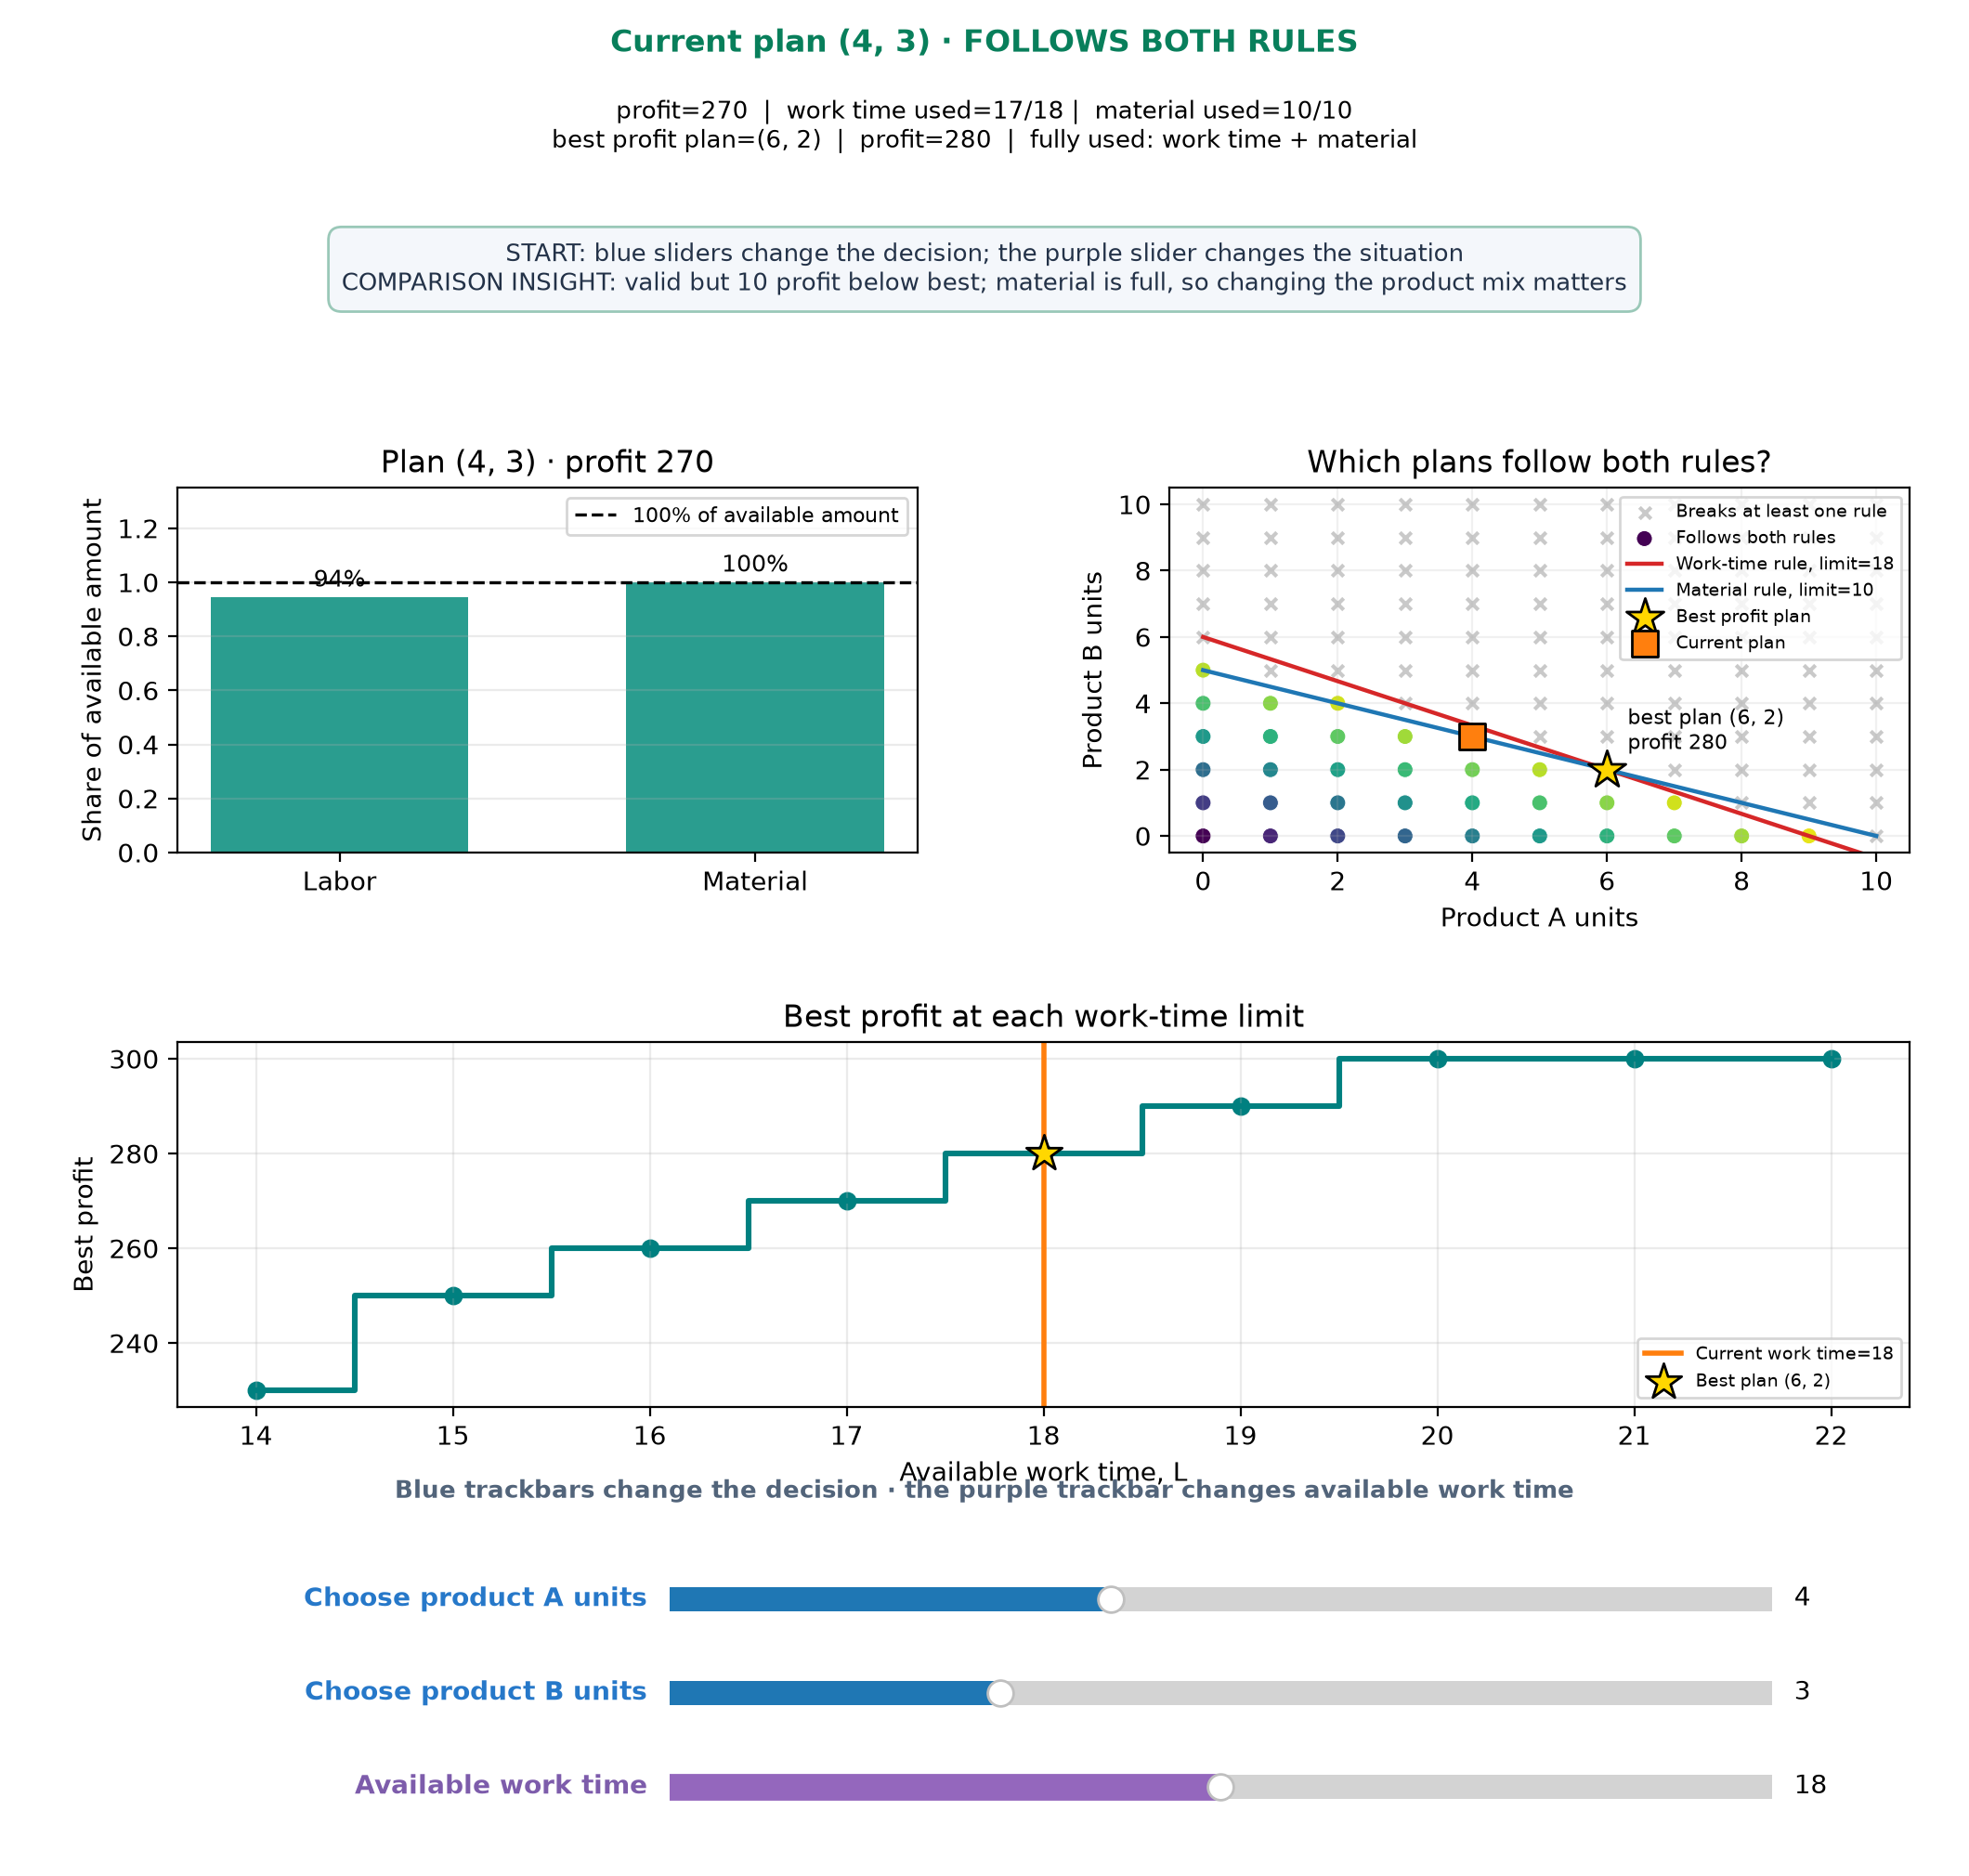

In [7]:
# This cell contains only the interactive graph.
with matplotlib.rc_context({"figure.dpi": matplotlib.rcParams["figure.dpi"] * 2}):
    decision_model = show_interactive_explorer()

### Takeaway

Use this order for any introductory optimization problem:

> **read the story → name the choices → calculate the results → check the constraints → compare the objective**

Lecture 02-1 writes the same reasoning in a compact mathematical form.